In [54]:
import pandas as pd
import numpy as np
from datetime import datetime
from penaltyblog.models import DixonColesGoalModel
from penaltyblog.ratings import Elo
import seaborn as sns
import matplotlib.pyplot as plt
from penaltyblog.models import create_dixon_coles_grid

In [2]:
# exemplo de jogos para ficar mais facil visualizar a execução do modelo
df = pd.DataFrame({
    'time-casa': ['Vasco',    'Fluminense', 'Vasco',      'Flamengo', 'Vasco',   'Flamengo',   'Flamengo', 'Botafogo',   'Fluminense', 'Botafogo', 'Botafogo', 'Fluminense'],
    'visitante': ['Flamengo', 'Botafogo',   'Fluminense', 'Botafogo', 'Botafogo', 'Fluminense', 'Vasco',    'Fluminense', 'Vasco',      'Flamengo', 'Vasco',   'Flamengo'],
    'gols-casa':      [1, 1, 1, 3, 0, 1, 2, 1, 1, 2, 2, 1],
    'gols-visitante': [2, 0, 0, 1, 2, 1, 0, 0, 0, 2, 1, 0],
})

df

,time-casa,visitante,gols-casa,gols-visitante
0,Vasco,Flamengo,1,2
1,Fluminense,Botafogo,1,0
2,Vasco,Fluminense,1,0
3,Flamengo,Botafogo,3,1
4,Vasco,Botafogo,0,2
5,Flamengo,Fluminense,1,1
6,Flamengo,Vasco,2,0
7,Botafogo,Fluminense,1,0
8,Fluminense,Vasco,1,0
9,Botafogo,Flamengo,2,2


In [3]:
# a distribuição Dixon-Coles é uma variação da distribuição de Poisson feita para esportes como Futebol, onde temos 2 valores e costumam ser pequenos
# Ele dá um peso maior para valores pequenos, principalmente os empates (0-0 e 1-1) que costumam ser subestimados. 
# Ele também abaixa um pouco as vitórias por pouco valor (1-0) que são hiper-valorizadas no Poisson, tornado-as muito provaveis mas menos que na versão tradicional
# Esse ajuste é feito com a constante rho, que é calculada a partir dos dados e devolvida pelo modelo
# Outras opções de distribuição que também se encaixam são a Zero Inflated Poisson e Binomial Negativa

modelo = DixonColesGoalModel(
  df["gols-casa"].to_numpy(copy=True),
  df["gols-visitante"].to_numpy(copy=True),
  df["time-casa"].to_numpy(copy=True), # to_numpy porque a biblioteca do modelo trabalha com números, não com dataframe e o copy é para que ele possa fazer alterações internas nos dados sem afetar os originais
  df["visitante"].to_numpy(copy=True),
) # params: gols do time da casa, gols do visitante, nome do time da casa, nome do visitante. Peso é opcional

modelo.fit() # define um valor de ataque e de defesa para cada time, uma constante de vantagem para o dono da casa
params = modelo.get_params()

params

{'attack_Botafogo': np.float64(1.4044516720995683),
 'attack_Flamengo': np.float64(1.5898664274773868),
 'attack_Fluminense': np.float64(0.540042362179757),
 'attack_Vasco': np.float64(0.4656395382432877),
 'defence_Botafogo': np.float64(-1.1563306569246286),
 'defence_Flamengo': np.float64(-1.2361007538765294),
 'defence_Fluminense': np.float64(-2.14802884092066),
 'defence_Vasco': np.float64(-1.1470584197726545),
 'home_advantage': np.float64(0.5094018474978182),
 'rho': np.float64(0.44863022022663335)}

In [51]:
# agora que temos o poder de ataque e defesa de cada time, o quanto a vantagem de campo afeta e o fator de ajuste para pequenos valores (rho)
# podemos usar esses dados para definir a chance de cada time vencer
# o método create_dixon_coles_grid permite a gente definir a expectativa de gols de cada time pra partida. A expectativa é definida a partir desses dados do treino

vasco_ataque = params['attack_Vasco']
vasco_defesa = params['defence_Vasco']
flamengo_ataque = params['attack_Flamengo']
flamengo_defesa = params['defence_Flamengo']

expect_gols_vasco = vasco_ataque + flamengo_defesa
expect_gols_fla = flamengo_ataque + vasco_defesa

# faz a conversão necessária dos valores
lambda_vasco = np.exp( expect_gols_vasco )
lambda_fla = np.exp( expect_gols_fla )

print(f'Lambda Vasco: {lambda_vasco}. Lambda Flamengo: {lambda_fla}')

Lambda Vasco: 0.4627995686841952. Lambda Flamengo: 1.557073359554069


In [7]:
# K é o quanto o Elo de um time muda com uma vitória ou derrota. Quanto maior K mais peso dá a jogos recentes e menos aos antigos
# Um site importante aplica Elo diferentes para cada torneio (60 copa, 50 continental, 40 eliminatorias, 20 amistoso e 30 os demais)
# a biblioteca encontrou 15 dando o menor erro para a Premier League

# home_field_advantage é quantos pontos ELO extras daremos ao dono da casa como vantagem
# a biblioteca recomenda 75
elo = Elo(k=15, home_field_advantage=75) # por default todo mundo começa com 1500 e vai mudando a cada jogo do dataset

for time in ['Vasco', 'Fluminense', 'Flamengo', 'Botafogo']:
    print('ELO inicial', time, ':', elo.get_team_rating(time))

ELO inicial Vasco : 1500.0
ELO inicial Fluminense : 1500.0
ELO inicial Flamengo : 1500.0
ELO inicial Botafogo : 1500.0


In [8]:
lista_gols_casa = df["gols-casa"].to_numpy()
lista_gols_visi = df["gols-visitante"].to_numpy()
lista_casa = df["time-casa"].to_numpy()
lista_visitante = df["visitante"].to_numpy()

# atualiza o ELO apos cada jogo
for i in range(len(df)):
    casa = lista_casa[i]
    visitante = lista_visitante[i]
    elo_casa = elo.get_team_rating(casa)
    elo_visit = elo.get_team_rating(visitante)

    if(lista_gols_casa[i] > lista_gols_visi[i]):
        result = 0
    else:
        if(lista_gols_casa[i] == lista_gols_visi[i]):
            result = 1 
        else: 
            result = 2
    elo.update_ratings(casa, visitante, result)

for time in ['Vasco', 'Fluminense', 'Flamengo', 'Botafogo']:
    print('ELO final', time, ':', elo.get_team_rating(time))

ELO final Vasco : 1471.4286607502436
ELO final Fluminense : 1507.5266565825996
ELO final Flamengo : 1513.2019181169683
ELO final Botafogo : 1507.8427645501886


In [49]:
# adiciona o Elo a lambda para influenciar a chance de gol de cada time
elo_vasco = elo.get_team_rating('Vasco')
elo_fla = elo.get_team_rating('Flamengo')

# Peso jogo: 80% dixon-coles e 20% ELO
peso_partida = 0.8 * (lambda_vasco - lambda_fla) + 0.2 * (elo_vasco - elo_fla)
print(f'Peso da partida: {peso_partida}')

soma_lambdas = lambda_vasco + lambda_fla
# atualiza os lambdas
lambda_vasco = (soma_lambdas + peso_partida)/2 # mandante recebe a media das lambdas com o peso
lambda_fla = (soma_lambdas - peso_partida)/2 # visitante recebe a diferença média das lambdas com o peso
print(f'Lambda intermediaria vasco: {lambda_vasco}. Lambda intermediaria Fla: {lambda_fla}')

# como lambda representa os gols esperados, ñ pode ser negativo. Portanto vamos considerar o menor valor como 0.05 (proximo de 0, mas com alguma chance de fazer gol ainda)
lambda_vasco = max(lambda_vasco, 0.05)
lambda_fla = max(lambda_fla, 0.05)
print(f'Lambda final vasco: {lambda_vasco}. Lambda final Fla: {lambda_fla}')

Peso da partida: -9.230070506040837
Lambda intermediaria vasco: -3.6050987889012864. Lambda intermediaria Fla: 5.624971717139551
Lambda final vasco: 0.05. Lambda final Fla: 5.624971717139551


In [52]:
# soma expectativa adicional de gols para o mandante
# no caso o mandante é o vasco
lambda_vasco *= np.exp(params['home_advantage'])

lambda_vasco

np.float64(0.7702351908305591)

In [63]:
# retorna o mesmo objeto do predict, portanto esse método faz a mesma função do predict 
# para quando vc já tem a previsão de gols vindas de algum lugar (como um bolão ou bet) ou quando quer dar seus proprios pesos a chance de gols
previsao = create_dixon_coles_grid(lambda_vasco, lambda_fla, params['rho'], max_goals=7)

print(f'Chance do mandante ganhar: {previsao.home_win}')
print(f'Chance de empate: {previsao.draw}')
print(f'Chance do visitante ganhar: {previsao.away_win}')
print('Todas as probabilidades de resultado:')
previsao.grid

Chance do mandante ganhar: 0.20506493065489811
Chance de empate: 0.1457835594946925
Chance do visitante ganhar: 0.6491515098504094
Todas as probabilidades de resultado:


array([[4.38874975e-02, 2.51264621e-01, 1.15168058e-01, 5.97750382e-02,
        2.32685299e-02, 7.24616160e-03, 1.88046753e-03, 4.18289414e-04],
       [9.84617024e-02, 6.28230881e-02, 8.87064910e-02, 4.60408380e-02,
        1.79222406e-02, 5.58124866e-03, 1.44840227e-03, 3.22181227e-04],
       [2.81812731e-02, 4.38803095e-02, 3.41624305e-02, 1.77311368e-02,
        6.90217019e-03, 2.14943707e-03, 5.57805199e-04, 1.24077659e-04],
       [7.23540275e-03, 1.12660529e-02, 8.77103539e-03, 4.55238185e-03,
        1.77209812e-03, 5.51857356e-04, 1.43213731e-04, 3.18563265e-05],
       [1.39324045e-03, 2.16937759e-03, 1.68894003e-03, 8.76601175e-04,
        3.41233084e-04, 1.06264989e-04, 2.75770639e-05, 6.13421593e-06],
       [2.14624565e-04, 3.34186193e-04, 2.60176209e-04, 1.35037815e-04,
        5.25659460e-05, 1.63698068e-05, 4.24816502e-06, 9.44957796e-07],
       [2.75518988e-05, 4.29003277e-05, 3.33994787e-05, 1.73351462e-05,
        6.74802357e-06, 2.10143355e-06, 5.45347699e-07, 1.

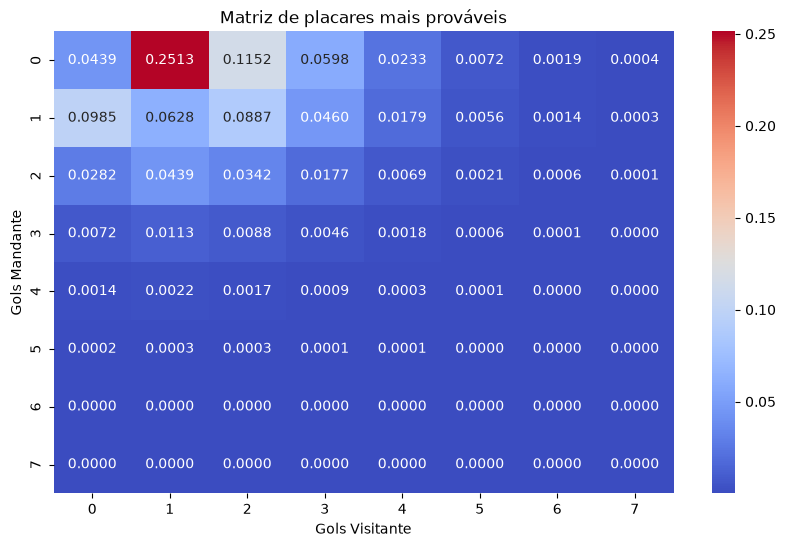

In [68]:
# Plot the heat map
matriz_placar = previsao.grid
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_placar, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Matriz de placares mais prováveis')
plt.xlabel("Gols Visitante")
plt.ylabel("Gols Mandante")
plt.show()

In [69]:
# pegando da matriz o valor mais provável
max_val = matriz_placar.max()
gols_mandante, gols_visitante = np.unravel_index(np.argmax(matriz_placar), matriz_placar.shape)

print(f"Placar mais provável: Vasco {gols_mandante} x Flamengo {gols_visitante}")

Placar mais provável: Vasco 0 x Flamengo 1
